# HOMEWORK 9

In this homework, you are going to use the dlib face detector and apply it to an image of your liking. You can follow the procedure shown in lesson 9. Please always comment your code so I can see what you're doing :-)

For this homework we are not going to provide you with any code, you'll have to build the face detector on your own.

### Step 0

Run the necessary imports.

In [1]:
import cv2
import dlib
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

### Step 1

Load an image (any image that contains faces).

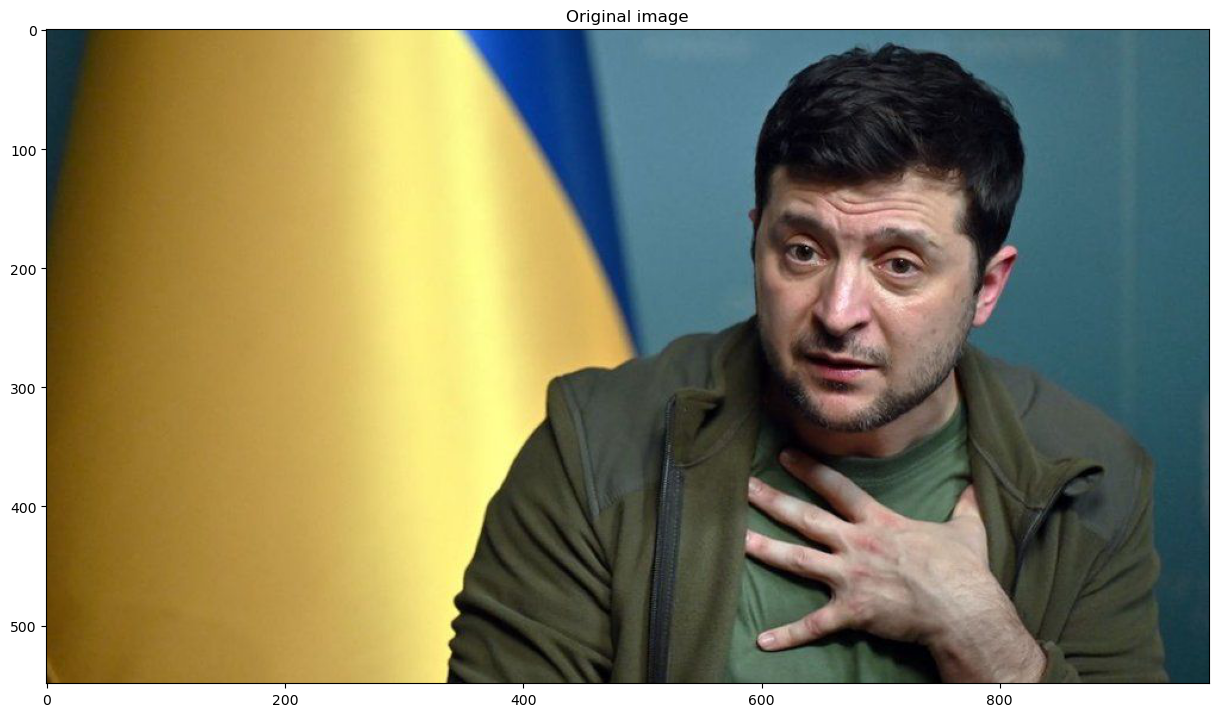

In [2]:
# Загружаем изображение с лицом
img = cv2.imread('zelensky.jpg')

# Конвертируем из BGR в RGB для корректного отображения в matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title('Original image')
plt.show()

### Step 2

Load the dlib face predictor.

In [3]:
# Создаём HOG-детектор лиц из dlib (предобученная модель, не требует внешних файлов)
detector = dlib.get_frontal_face_detector()
print('Детектор загружен')

Детектор загружен


### Step 3

Run the predictor on your image.

In [4]:
# Запускаем детектор на изображении
# Второй аргумент — количество upsampling-ов (увеличивает изображение для поиска маленьких лиц)
# Для zelensky.jpg лицо крупное, так что 1 достаточно
detections = detector(img_rgb, 1)

# Выводим количество найденных лиц
print(f'Найдено лиц: {len(detections)}')

Найдено лиц: 1


### Step 4

Draw bounding boxes around the detected faces and plot the image. Use different colour for each face.

Лицо 1: (563, 118) -> (786, 341)


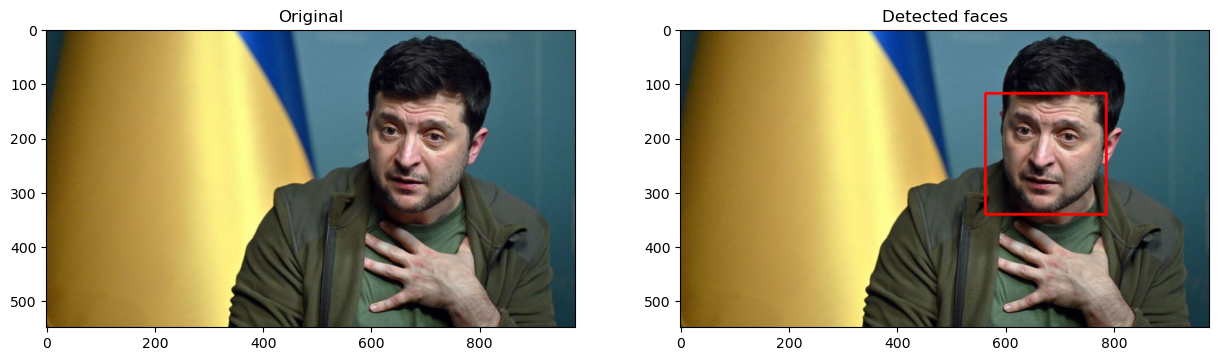

In [5]:
# Список цветов для рамок (RGB) — разный цвет для каждого лица
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (255, 0, 255), (0, 255, 255)]

# Копируем изображение, чтобы не менять оригинал
out = np.copy(img_rgb)

# Рисуем bounding box вокруг каждого найденного лица
for i, det in enumerate(detections):
    # Достаём координаты прямоугольника
    x1 = det.left()
    y1 = det.top()
    x2 = det.right()
    y2 = det.bottom()
    
    # Выбираем цвет (циклически, если лиц больше чем цветов)
    color = colors[i % len(colors)]
    
    # Рисуем прямоугольник
    cv2.rectangle(out, (x1, y1), (x2, y2), color, 3)
    print(f'Лицо {i+1}: ({x1}, {y1}) -> ({x2}, {y2})')

plt.subplot(121), plt.imshow(img_rgb), plt.title('Original')
plt.subplot(122), plt.imshow(out), plt.title('Detected faces')
plt.show()

### Step 5 (optional)

Repeat the process with a different and more challenging image (more faces, smaller faces, people with glasses, hats, helmets, etc.). How does the detector perform? Is it robust?

Найдено лиц (upsample=1): 8


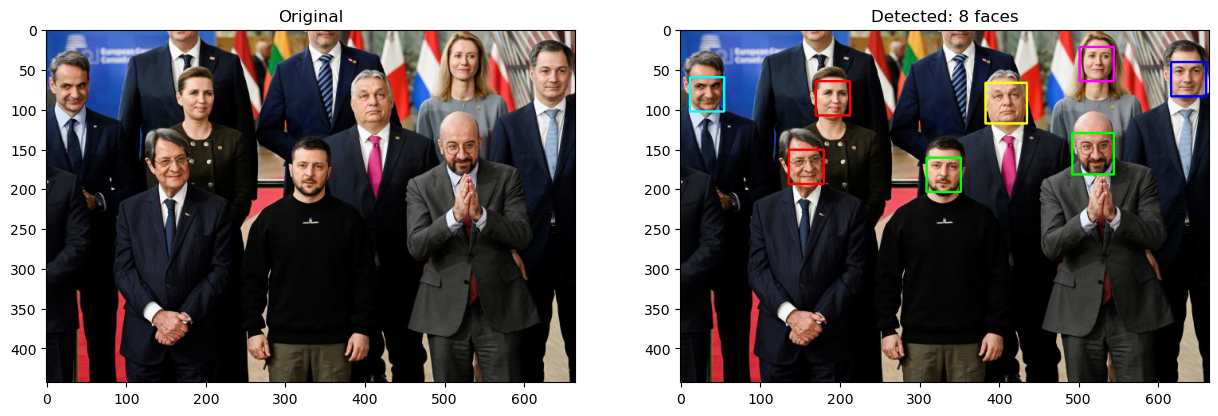

In [6]:
# Загружаем более сложное изображение — фото саммита ЕС с множеством лиц
img2 = cv2.imread('eu_summit.jpg')
img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# Запускаем детектор (upsample=1)
detections2 = detector(img2_rgb, 1)
print(f'Найдено лиц (upsample=1): {len(detections2)}')

# Рисуем bounding boxes
out2 = np.copy(img2_rgb)
for i, det in enumerate(detections2):
    x1, y1, x2, y2 = det.left(), det.top(), det.right(), det.bottom()
    color = colors[i % len(colors)]
    cv2.rectangle(out2, (x1, y1), (x2, y2), color, 2)

plt.subplot(121), plt.imshow(img2_rgb), plt.title('Original')
plt.subplot(122), plt.imshow(out2), plt.title(f'Detected: {len(detections2)} faces')
plt.show()

Найдено лиц (upsample=2): 8


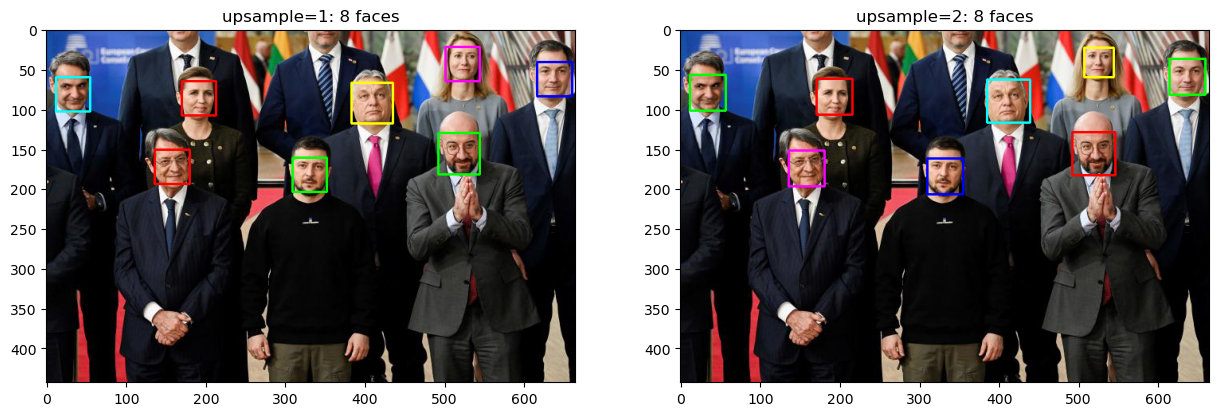

In [7]:
# Попробуем увеличить upsample до 2 — это поможет найти более мелкие лица
detections2_up = detector(img2_rgb, 2)
print(f'Найдено лиц (upsample=2): {len(detections2_up)}')

out2_up = np.copy(img2_rgb)
for i, det in enumerate(detections2_up):
    x1, y1, x2, y2 = det.left(), det.top(), det.right(), det.bottom()
    color = colors[i % len(colors)]
    cv2.rectangle(out2_up, (x1, y1), (x2, y2), color, 2)

plt.subplot(121), plt.imshow(out2), plt.title(f'upsample=1: {len(detections2)} faces')
plt.subplot(122), plt.imshow(out2_up), plt.title(f'upsample=2: {len(detections2_up)} faces')
plt.show()

**Наблюдения:**

На простом изображении (Зеленский) детектор без проблем находит лицо — оно крупное, фронтальное, хорошо освещённое.

На групповом фото с саммита ЕС ситуация сложнее. С `upsample=1` детектор находит не все лица — особенно пропускает те, что в заднем ряду (они мелкие). Если увеличить `upsample` до 2, находится больше лиц, потому что изображение масштабируется вверх и мелкие лица становятся достаточно крупными для HOG-дескриптора.

В целом детектор довольно робастный для фронтальных лиц, но у него есть ограничения: он хуже справляется с лицами, повёрнутыми в профиль, частично перекрытыми другими людьми, или слишком маленькими. Это ожидаемо для HOG-based подхода.